In [6]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [7]:
csv_files = [
    'northchowan.csv', #*****
    'edentonbay.csv',#*****
    'midchowan.csv', #*****
    'albemarle.csv', #*****
    'bridge.csv'
]
filtered_dfs = {}
date_range = pd.date_range(start='2016-01-01', end='2024-06-30', freq='D').strftime('%m-%d-%Y')

def preprocess_and_expand(file, date_range):
    df = (
        pd.read_csv(file, parse_dates=['date'], infer_datetime_format=True)
        .sort_values(by='date')
    )
    df['date'] = df['date'].dt.strftime('%m-%d-%Y')
    df = df.loc[df['pred'] == 1].drop_duplicates()
    # Expand to the full date range
    full_dates = pd.DataFrame({'date': date_range})
    expanded_df = full_dates.merge(df, on='date', how='left')
    expanded_df[['pred']] = expanded_df[[ 'pred']].fillna(0).astype(int)
    return expanded_df

processed_dfs = {}

for file in csv_files:
    key = file.split('.')[0]
    processed_dfs[key] = preprocess_and_expand(file, date_range)

In [8]:
df7 = processed_dfs['edentonbay']
df7 = df7.loc[df7['pred'] == 1].drop_duplicates()
df7 = df7.iloc[102:115]
# df7

In [9]:
df7

,date,pred
2010,07-03-2021,1
2011,07-04-2021,1
2013,07-06-2021,1
2014,07-07-2021,1
2029,07-22-2021,1
2032,07-25-2021,1
2048,08-10-2021,1
2049,08-11-2021,1
2055,08-17-2021,1
2061,08-23-2021,1


In [10]:
d= pd.read_excel('Sites with algal cell data V2.xlsx',header=0)#, parse_dates=['date'], infer_datetime_format=True)
d = d.drop(['albemarle', 'midchowan', 'northchowan','bridge'], axis=1)  
df = d.drop(d.columns[d.columns.str.startswith('Unnamed:')], axis=1)
df = df.iloc[62:78]

df['DEQ'] = pd.to_datetime(df['DEQ'])
df7['date'] = pd.to_datetime(df7['date'])
df.set_index('DEQ', inplace=True)

In [11]:
df

,edenton
DEQ,
2021-06-07,0
2021-06-09,0
2021-06-14,0
2021-06-15,0
2021-06-29,32096
2021-07-13,0
2021-07-15,0
2021-07-20,0
2021-07-21,19720


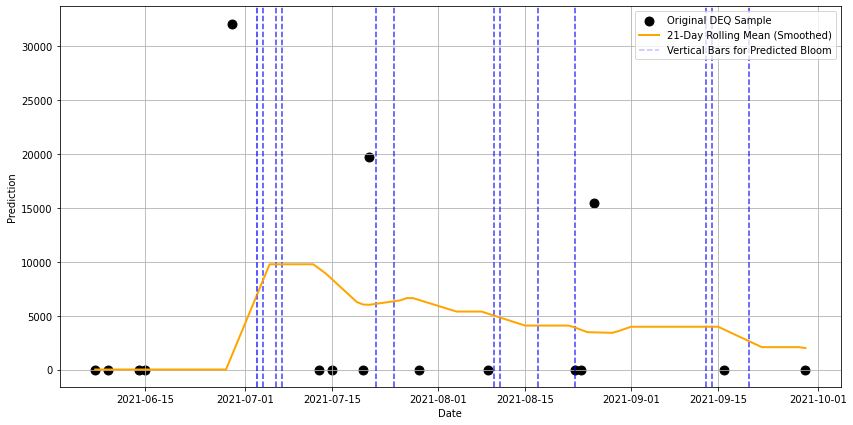

In [12]:
resampled_df = df.resample('D').mean()
resampled_df['exp'] = resampled_df['edenton'].ewm(alpha=.1, adjust=False).mean()
resampled_df['rolling_mean'] = resampled_df['exp'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(14, 7))
for date in df7['date']:
    plt.axvline(x=date, color='blue', alpha=0.75,linestyle='--', label='_nolegend_')  # Avoid duplicate legend entries

plt.scatter(resampled_df.index, resampled_df['edenton'], label='Original DEQ Sample', c='k', s=80, marker='o')
plt.plot(resampled_df.index, resampled_df['rolling_mean'], label=f'{21}-Day Rolling Mean (Smoothed)', color='orange', linewidth=2)
plt.axvline(x=df7['date'].iloc[0], color='blue', alpha=0.25,linestyle='--', label='Vertical Bars for Predicted Bloom')

# plt.title('Rolling Mean of DEQ Counts over North Chowan 2021')
plt.xlabel('Date')
plt.ylabel('Prediction')
plt.legend(loc=1)
plt.grid(True)
# plt.savefig('Figures/roling_northchowan.png', transparent=False, dpi=100, facecolor='white', bbox_inches='tight')
plt.show()


In [13]:
resampled_df= resampled_df.drop(resampled_df.columns[resampled_df.columns.str.startswith('Unnamed:')], axis=1)


dfs = processed_dfs['edentonbay']
dfs['date'] = pd.to_datetime(dfs['date'])
resampled_df.index = pd.to_datetime(resampled_df.index)
resampled_df_reset = resampled_df.reset_index()
merged_df = pd.merge(resampled_df_reset, dfs, left_on='DEQ',right_on = 'date', how='inner')
merged_df = merged_df.drop(['date'], axis=1)  

from scipy.stats import mannwhitneyu

group_0 = merged_df.loc[merged_df["pred"] == 0, "rolling_mean"].dropna()  # Group with pred = 0
group_1 = merged_df.loc[merged_df["pred"] == 1, "rolling_mean"].dropna()  # Group with pred = 1

if len(group_0) > 0 and len(group_1) > 0:
    stat, p_value = mannwhitneyu(group_0, group_1, alternative='two-sided')

    print("Mann-Whitney U Test:")
    print(f"Statistic: {stat}, p-value: {p_value}")
else:
    print("Insufficient data for the test: one of the groups is empty.")


Mann-Whitney U Test:
Statistic: 396.0, p-value: 0.018083454805135617


In [ ]:
# Get summary statistics for rolling_mean
# print("Summary Statistics for pred=0:")
# print(df_pred_0['rolling_mean'].describe())
# print("\nSummary Statistics for pred=1:")
# print(df_pred_1['rolling_mean'].describe())


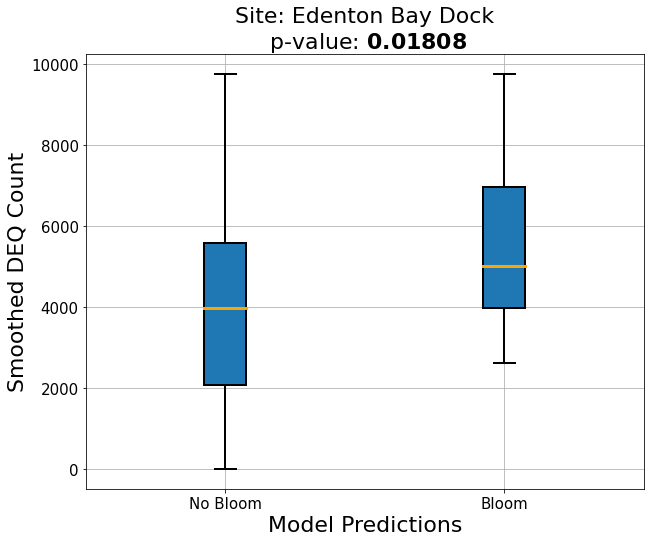

In [27]:
df_pred_0 = merged_df[merged_df['pred'] == 0]
df_pred_1 = merged_df[merged_df['pred'] == 1]


box_colors = ['lightblue', 'lightcoral']

# Create box-and-whisker plots
f, ax = plt.subplots(figsize=(10, 8))
boxplot = ax.boxplot(
    [df_pred_0['rolling_mean'].dropna(), df_pred_1['rolling_mean'].dropna()],
    labels=['No Bloom', 'Bloom'],
    patch_artist=True,  # Allows filling the boxes with color
    medianprops={'linewidth': 3, 'color': 'orange'},  # Make median thicker
    boxprops={'linewidth': 2},  # Box border thickness
    capprops={'linewidth': 2},  # End caps thickness
    whiskerprops={'linewidth': 2},  # Whisker thickness
    flierprops={'marker': 'o', 'markersize': 6, 'markerfacecolor': 'gray', 'markeredgewidth': 1}  # Outlier styling
)


# Add titles and labels
ax.set_title("Site: Edenton Bay Dock\n " + r"p-value: $\bf{" + str(round(p_value, 5)) + "}$", fontsize=22)
ax.set_xlabel('Model Predictions',fontsize=22)
ax.set_ylabel('Smoothed DEQ Count',fontsize=22)
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.grid(True)
plt.savefig('eden_p.png', dpi = 100,  facecolor='white')
plt.show()


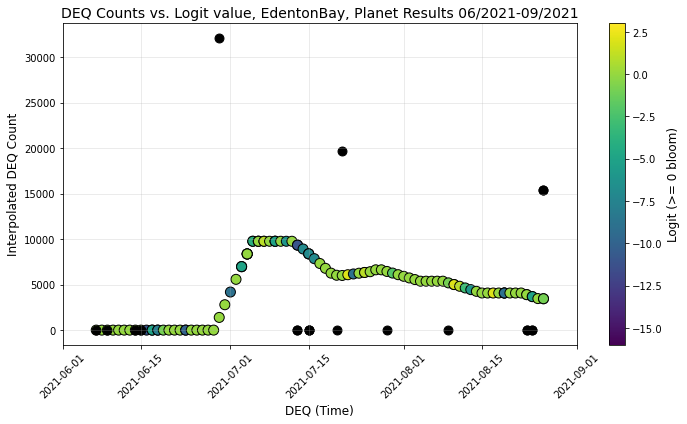

In [42]:
import matplotlib.colors as mcolors

merged_df["DEQ"] = pd.to_datetime(merged_df["DEQ"])

# Create a scatter plot
plt.figure(figsize=(10, 6))

# Normalize the 'pred' column for the color scale
norm = mcolors.Normalize(vmin=merged_df["pred"].min(), vmax=merged_df["pred"].max())
cmap = plt.cm.viridis

# Scatter plot
sc = plt.scatter(
    merged_df["DEQ"], merged_df["rolling_mean"], c=merged_df["pred"], cmap=cmap, norm=norm, s=100, edgecolor='k')
# DEQ countw

plt.scatter(merged_df["DEQ"], merged_df['D999500N'], label='Original Data (DEQ Samples)', c='k', s=80, marker='o')


# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Logit (>= 0 bloom)", fontsize=12)

# Formatting the plot
plt.xlim(pd.to_datetime('06-01-2021'), pd.to_datetime('09-01-2021'))

plt.xlabel("DEQ (Time)", fontsize=12)
plt.ylabel("Interpolated DEQ Count", fontsize=12)
plt.title("DEQ Counts vs. Logit value, EdentonBay, Planet Results 06/2021-09/2021", fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('logit_comp.png', dpi = 100,  facecolor='white')

plt.show()


In [ ]:
#Edenton bay, df7 = df7.iloc[102:115]
